ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [141]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [142]:
# Load Dataset
df = pd.read_csv("/content/Video Games Sales (1980-2024) - Raw.csv")# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)



,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64010,/games/boxart/full_2294305JapanFrontccc.jpg,World End Syndrome,PS4,Visual Novel,Arc System Works,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,26-04-2018,03-04-2019
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,11-08-2016,28-01-2019
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,30-07-2020,09-05-2020
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,30-07-2020,09-05-2020


In [143]:
#for feature anaylsis
df_before = df.copy()

# **Data Overview Section**


---





The dataset was explored by checking its shape, data types, missing values, and duplicate records. Summary statistics were also generated to understand the distribution of the data.

In [144]:
# Data Overview

# 1. Shape
print("Shape (rows, columns): ", df.shape,"\n")

# 2. Info
df.info()

Shape (rows, columns):  (64016, 14) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [145]:
# 3. Missing values

print(df.isna().sum())

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64


Missing values were identified in several columns such as total_sales and critic_score.

In [146]:
# 4. Duplicates

df.duplicated()[df.duplicated()==True]

,0


In [147]:
# 5. Statistics

df.describe(include='all')

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
count,64016,64016,64016,64016,64016,63999,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000,56965,17879
unique,56177,39798,81,20,3383,8862,NaN,NaN,NaN,NaN,NaN,NaN,7922,1545
top,/games/boxart/default.jpg,Plants vs. Zombies,PC,Misc,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,01-01-1994,06-01-2018
freq,7810,17,12617,9304,8842,4435,NaN,NaN,NaN,NaN,NaN,NaN,515,165
mean,NaN,NaN,NaN,NaN,NaN,NaN,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000,NaN,NaN


# **Data Cleaning Section**


---



In [148]:
df.drop(['img','last_update'], axis=1, inplace=True)

Unnecessary columns such as 'img' and 'last_update' were removed because they do not contribute to the analysis and may add noise to the dataset.


---



In [149]:
df = df.drop(columns=['na_sales', 'jp_sales', 'pal_sales', 'other_sales'])

Regional sales columns (NA, JP, PAL, Other) contained a large number of missing values and These columns will not be used in the analysis. Therefore, they were removed to simplify the dataset and focus on total sales.


---



In [150]:
df = df.dropna(subset=['total_sales'])

Rows with missing values in the 'total_sales' column were removed because this column is essential for the analysis of video game performance.


---



In [151]:
df['critic_score'].fillna(df['critic_score'].median(), inplace=True)

/tmp/ipykernel_15703/554450444.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['critic_score'].fillna(df['critic_score'].median(), inplace=True)


Missing values in the 'critic_score' column were filled using the median value to preserve the dataset size and reduce the impact of outliers.


---



In [152]:
df['developer'] = df['developer'].fillna("Unknown")

Missing values in the developer column were replaced with "Unknown" due to the small number of missing entries.


---



In [154]:
df['release_date'] = pd.to_datetime(df['release_date'])

df['year'] = df['release_date'].dt.year

df = df.drop(columns=['release_date'])

/tmp/ipykernel_15703/4137454296.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['release_date'] = pd.to_datetime(df['release_date'])


The year was extracted from the release_date column to simplify time-based analysis and the original release_date column was removed to avoid redundancy.

In [155]:
df = df.dropna(subset=['year'])

Rows with missing year values were removed because the year is essential for time-based analysis.


---




### Before Cleaning **vs** After Cleaning

In [172]:
print('The Shape Differance:')
print("Before:", df_before.shape)
print("After:", df.shape)

The Shape Differance:
Before: (64016, 14)
After: (18832, 8)


The dataset size significantly decreased after cleaning, from 64,016 rows to 18,832 rows. This indicates that a large portion of the data contained missing or incomplete values. Removing these rows improved the quality and reliability of the dataset for further analysis.

---



# **Descriptive summary Statistics Section**



---




### Univariate Analysis

Distribution of Total Game Sales

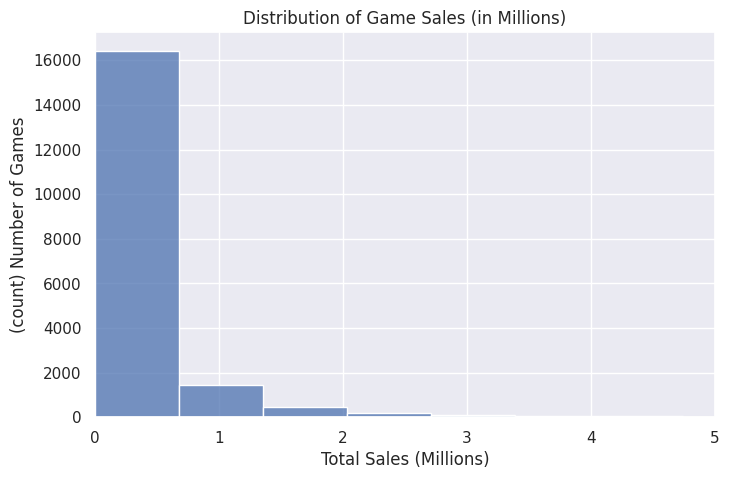

In [157]:
plt.figure(figsize=(8,5))

sns.histplot(df['total_sales'], bins=30)

plt.xlabel("Total Sales (Millions)")
plt.ylabel("(count) Number of Games")
plt.title("Distribution of Game Sales (in Millions)")

plt.xlim(0,5)

plt.show()

- Shows how total game sales are distributed
- Most games have low sales (less than 1 million)  
- Few games have very high sales, resulting in a right-skewed distribution

Distribution of Critic Scores

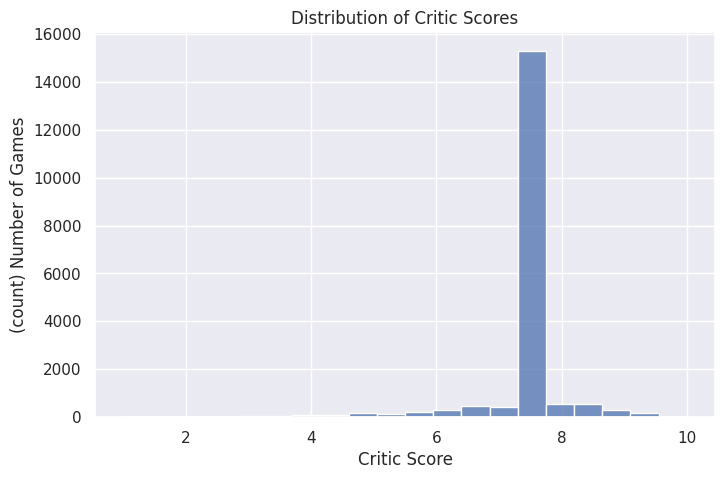

In [158]:
plt.figure(figsize=(8,5))

sns.histplot(df['critic_score'], bins=20)

plt.xlabel("Critic Score")
plt.ylabel("(count) Number of Games")
plt.title("Distribution of Critic Scores")

plt.show()

- Shows the distribution of critic scores for video games  
- Most games have moderate to high scores, typically between 6 and 9  
- Very low scores are uncommon

Number of Games by Genre

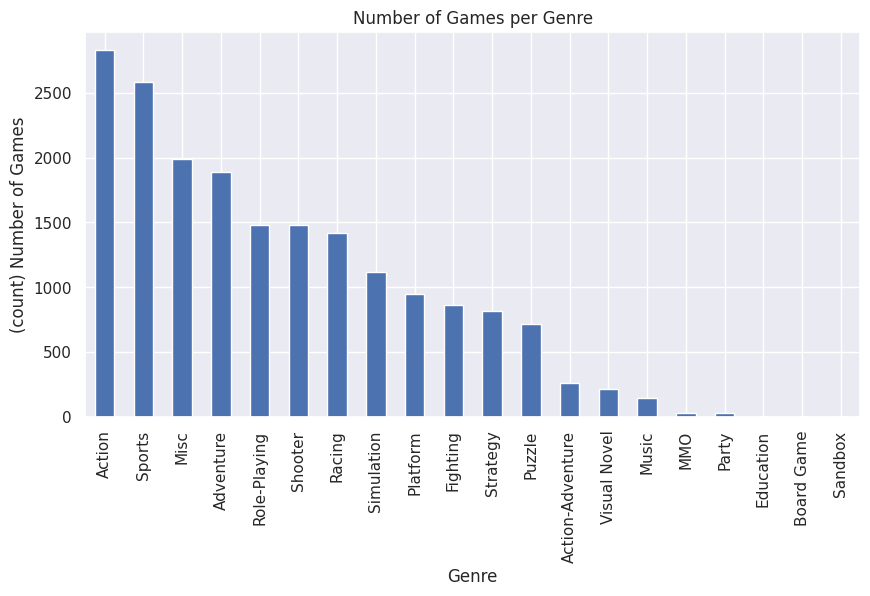

In [173]:
plt.figure(figsize=(10,5))

df['genre'].value_counts().plot(kind='bar')

plt.xlabel("Genre")
plt.ylabel("(count) Number of Games")
plt.title("Number of Games per Genre")

plt.show()

• Shows the number of games in each genre  
• Some genres have significantly more games than others, indicating that certain types of games are more popular among developers  



## Bivariate Analysis


Critic Score vs Total Sales

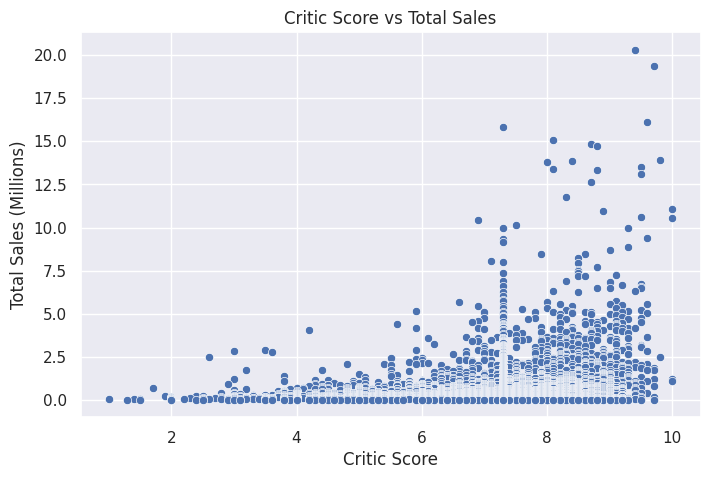

In [160]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['critic_score'], y=df['total_sales'])

plt.xlabel("Critic Score")
plt.ylabel("Total Sales (Millions)")
plt.title("Critic Score vs Total Sales")

plt.show()

• Shows the relationship between critic scores and total sales  
• Games with higher scores tend to have better sales however, the relationship is not very strong  
• Some games achieve high sales despite moderate scores  

Total Sales by Genre

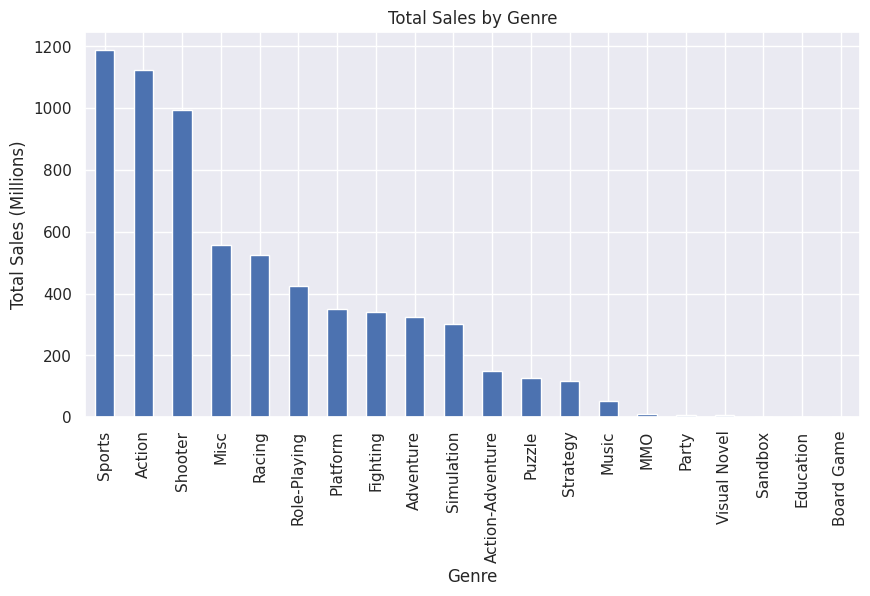

In [161]:
plt.figure(figsize=(10,5))

df.groupby('genre')['total_sales'].sum().sort_values(ascending=False).plot(kind='bar')

plt.xlabel("Genre")
plt.ylabel("Total Sales (Millions)")
plt.title("Total Sales by Genre")

plt.show()

• Shows the total sales generated by each game genre  
• Some genres clearly dominate the market in terms of sales  
• This indicates that certain types of games are more successful and widely preferred  

Top Publishers by Total Sales

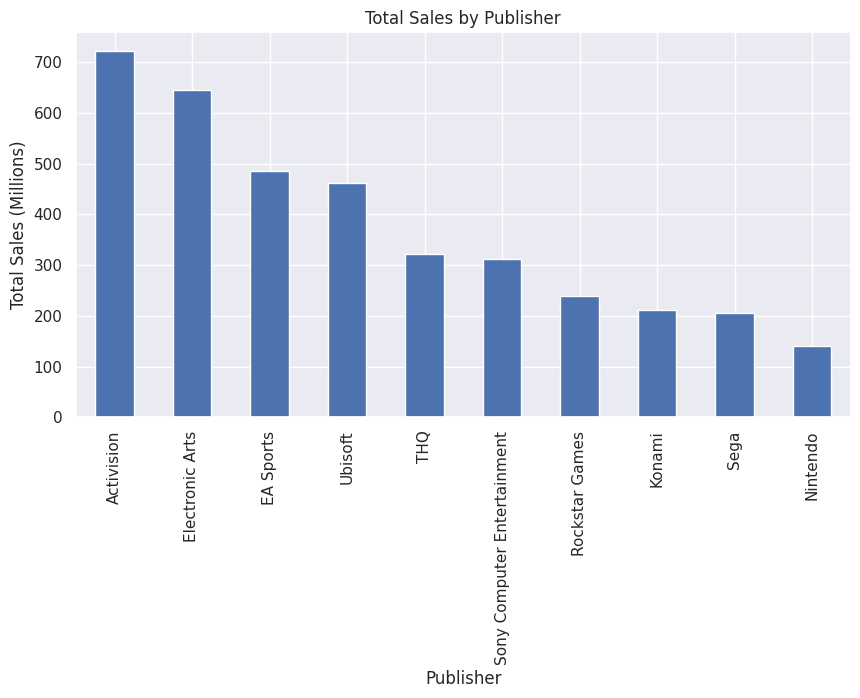

In [162]:
plt.figure(figsize=(10,5))

df.groupby('publisher')['total_sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

plt.xlabel("Publisher")
plt.ylabel("Total Sales (Millions)")
plt.title("Total Sales by Publisher")

plt.show()

plt.show()

• Shows the total sales generated by the top game publishers  
• A few publishers dominate the market with significantly higher sales  
• This highlights the strong influence of leading companies in the gaming industry  

Top 10 Best-Selling Games

In [163]:
top_games = df.sort_values(by='total_sales', ascending=False)

top_games[['title', 'total_sales']].head(10)

,title,total_sales
0,Grand Theft Auto V,20.32
1,Grand Theft Auto V,19.39
2,Grand Theft Auto: Vice City,16.15
3,Grand Theft Auto V,15.86
4,Call of Duty: Black Ops 3,15.09
5,Call of Duty: Modern Warfare 3,14.82
6,Call of Duty: Black Ops,14.74
7,Red Dead Redemption 2,13.94
8,Call of Duty: Black Ops II,13.86
9,Call of Duty: Black Ops II,13.80


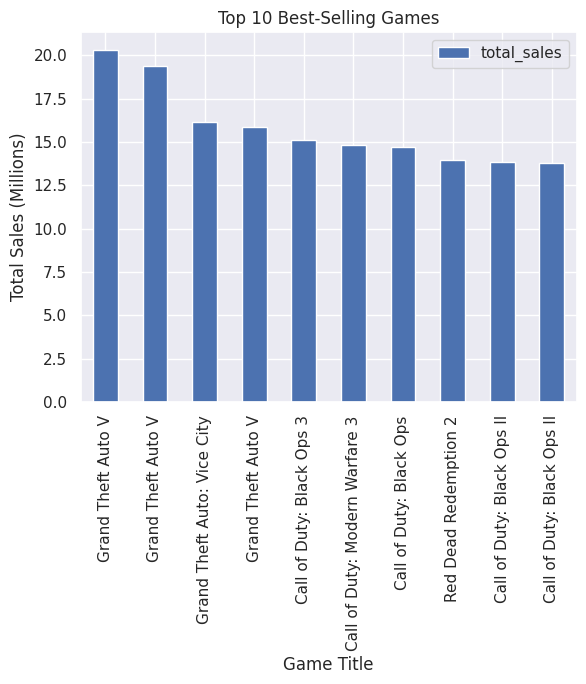

In [164]:
top_games.head(10).plot(kind='bar', x='title', y='total_sales')

plt.xlabel("Game Title")
plt.ylabel("Total Sales (Millions)")
plt.title("Top 10 Best-Selling Games")

plt.show()

• Shows the top 10 best-selling video games  
• These games achieved significantly higher sales compared to others  
• This highlights the most successful titles in the dataset  

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Time-Based Analysis


Total Sales Over Time

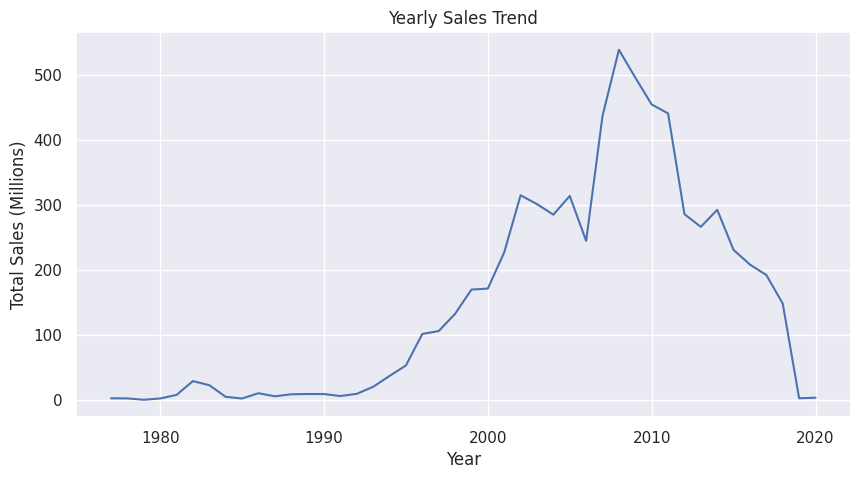

In [165]:
yearly_sales = df.groupby('year')['total_sales'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot()

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales (Millions)")

plt.show()

• Shows the trend of total game sales over the years  
• Sales were relatively low in earlier years and increased significantly after 2000  
• The peak occurred around 2008–2010  
• After that, sales began to decline  

# **Conclusion**

In this analysis, the dataset was cleaned and prepared to improve its quality and reliability.
Necessary adjustments were made, including handling missing values, simplifying the data, and improving its structure for better analysis.


The visualizations were used to understand key aspects of the video game market.
They helped identify periods when interest in games increased, as well as the companies that dominate the market in terms of sales.
Differences between genres also highlighted variations in popularity and performance.
Additionally, the relationship between critic scores and sales showed that higher ratings do not always guarantee higher success.



Overall, this analysis provides useful insights into the video game industry and highlights the main factors that influence game performance and success.

In [170]:
df.head(-1)

,title,console,genre,publisher,developer,critic_score,total_sales,year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,2002.0
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.3,15.86,2013.0
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,2015.0
...,...,...,...,...,...,...,...,...
18916,Teslagrad,PSV,Platform,Rain Games,Rain Games,7.3,0.00,2014.0
18917,Teslagrad,WiiU,Platform,Rain Games,Rain Games,7.0,0.00,2014.0
18918,Open Season,XB,Platform,Ubisoft,Ubisoft Montreal,6.4,0.00,2006.0
18919,The SpongeBob SquarePants Movie,PC,Platform,THQ,Heavy Iron Studios,6.0,0.00,2004.0


In [168]:
df.to_excel("cleaned_data.xlsx", index=False)

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
